# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 1</span>
### <span style= "color: black" > Es01.1


**Pt.1**

In questo esercizio si vuole valutare il seguente integrale:

$$
\langle r \rangle = \int_0^1 r\,dr = \frac{1}{2}.
$$

Per farlo viene utilizzato un generatore di numeri casuali, la cui affidabilità verrà testata successivamente nell'esercizio.

L'integrale viene stimato numericamente mediante il metodo Monte Carlo. Infatti, generando $M$ valori pseudo-casuali $r_i$ uniformemente distribuiti nell'intervallo $[0,1]$, il valore dell'integrale può essere approssimato mediante la media campionaria:

$$
\langle r \rangle \simeq \frac{1}{M}\sum_{i=1}^{M}r_i.
$$

Per stimare sia il valore dell'integrale sia la relativa incertezza statistica, i valori casuali generati vengono trattati mediante il metodo del **data blocking**. In particolare, vengono generate $M=10^4$ misure, successivamente suddivise in $N=100$ blocchi, ciascuno contenente

Per ogni blocco viene calcolata una media $A_i$, detta *block average*:

$$
A_i=\frac{1}{L}\sum_{j=1}^{L}A_{i,j},
\qquad i=1,\ldots,N.
$$

Nel caso considerato, la grandezza $A_{i,j}$ coincide con il numero casuale $r$ generato a ogni estrazione.
La stima della quantità considerata si ottiene calcolando la media delle medie a blocchi:

$$
\langle A\rangle_N=\frac{1}{N}\sum_{i=1}^{N}A_i
$$

e la sua incertezza statistica viene stimata come la deviazione standard della media degli $A_i$ 

$$
\sigma_{\langle A\rangle}
=
\sqrt{
\frac{
\langle A^2\rangle_N-\langle A\rangle_N^2
}{N-1}
},
$$

dove

$$
\langle A^2\rangle_N
=
\frac{1}{N}\sum_{i=1}^{N}A_i^2.
$$

La suddivisione in blocchi è particolarmente utile quando le misure successive sono correlate poiché se la lunghezza $L$ dei blocchi è sufficientemente maggiore della lunghezza di correlazione dei dati, le medie dei diversi blocchi possono essere considerate approssimativamente indipendenti.

La scelta del numero di blocchi $N$ richiede quindi un compromesso. Un valore di $N$ troppo grande corrisponde a blocchi troppo corti, che potrebbero non eliminare le correlazioni tra misure successive e portare a una sottostima dell'incertezza. Al contrario, un valore di $N$ troppo piccolo produce pochi valori $A_i$ e rende meno affidabile la stima statistica dell'errore.

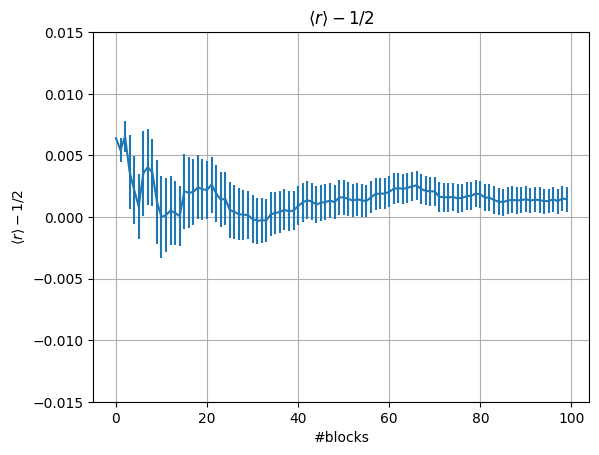

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# Funzione per leggere i dati da file e rappresentarli
def plot(filename, title, ymin, ymax):
    # Caricamento dei dati
    x, f, error = np.loadtxt(filename, usecols=(0, 1, 2), delimiter=' ', unpack=True)

    # Grafico dei valori con le relative barre di errore
    plt.errorbar(x, f, yerr=error)

    # Impostazione delle etichette, dei limiti e del titolo
    plt.xlabel('#blocks')
    plt.ylabel(title)
    plt.ylim(ymin, ymax)
    plt.grid(True)
    plt.title(title)
    plt.show()
    
plot("Es01.1/output.txt", r'$\langle r \rangle - 1/2$', -0.015, 0.015)

Il grafico mostra la stima di $\langle r \rangle - 1/2$ in funzione del numero di blocchi, con la relativa incertezza statistica, calcolata come deviazione standard della media della stima di $\langle r \rangle$.

So oseerva che il valore atteso tende a 0 e che l'errore statistico descresce con l'aumentare del numero dei blocchi.

**Pt.2**

Ora si vuole valutare un altro integrale, questa volta : $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$. La procedura per ottenere la stima dell’integrale in funzione del numero di blocchi e la relativa incertezza è la stessa usata in precedenza.

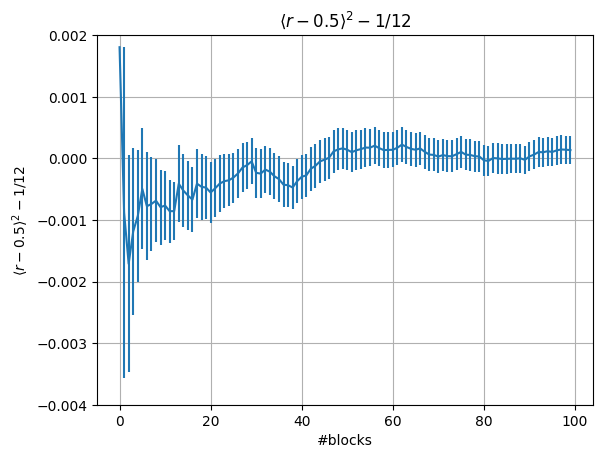

In [2]:
plot("Es01.1/output2.txt", r'$\langle r -0.5\rangle^2 - 1/12$', -0.004, 0.002)

Come nel caso precedente, si osserva il comportamento atteso: la stima di $\int_0^1 (r-1/2)^2 dr - 1/12$ tende a 0 e la relativa incertezza diminuisce all’aumentare del numero di blocchi.

**Pt.3**

Come già detto, per stimare i valori degli integrali è stato utilizzato un generatore di numeri pseudo-casuali uniformemente distribuiti nell’intervallo $[0,1)$. **Ma possiamo considerare questi numeri effettivamente compatibili con una distribuzione uniforme?**

Poiché non è possibile dimostrare in modo assoluto che un insieme finito di numeri pseudo-casuali sia estratto da una distribuzione uniforme, viene applicato un test statistico per verificare se tale ipotesi possa essere rifiutata. Per farlo l’intervallo $[0,1]$ viene diviso in $M = 100$ sottointervalli identici e si applica il test del $\chi^2$.

Il chi quadro misura lo scarto tra i valori osservati, $O_i$, e i valori attesi, $E_i$:

$$
\chi^2 = \sum_i \frac{(O_i - E_i)^2}{E_i}
$$

S generano quindi $n = 10^4$ numeri pseudo-casuali e si contano quanti di essi cadono in ciascun sottointervallo. Se i numeri sono uniformemente distribuiti (è l'ipotesi!), il numero atteso di eventi in ogni sottointervallo è

$$
E_i = np = n \frac{1}{M} = \frac{n}{M}.
$$

Il test viene ripetuto 100 volte, usando ogni volta un nuovo gruppo di $10^4$ numeri pseudo-casuali.

Nel grafico seguente vengono mostrati i valori di chi quadro ottenuti per ogni test $j$, con $j = 1,\dots,100$. Ci si aspetta in media che $(n_i - n/M)^2 \simeq n/M$ e quindi che $\chi^2 \simeq 100$, cioè circa pari al numero di sottointervalli. Un valore più grande di $\chi^2$ indica che l’ipotesi che gli $n_i$ siano estratti da una distribuzione uniforme è poco probabile.

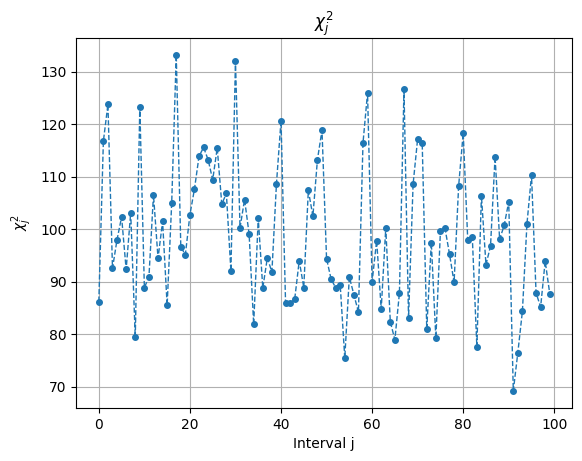

In [ ]:
#Plot Chi quadro 
x,f= np.loadtxt('Es01.1/outputCHI2.txt', usecols=(0,1), delimiter=' ', unpack='true') 
plt.errorbar(x,f, fmt='--o', linewidth=1, markersize=4) 
plt.xlabel('Interval j') 
plt.ylabel('$\chi^2_j$')
plt.grid(True)
plt.title('$\chi^2_j$')
plt.show()

Per comprendere meglio i risultati, l’istogramma dei valori ottenuti viene confrontato con la distribuzione teorica $\chi^2_j$ (l’istogramma è normalizzato per confrontarlo con la distribuzione di probabilità).

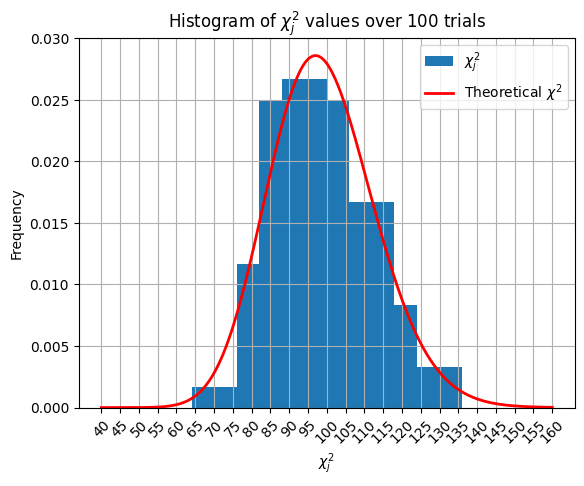

In [ ]:
from scipy.stats import chi2

M = 100

x = np.loadtxt('Es01.1/outputCHI2.txt',usecols=(1), delimiter=' ', unpack='true')

n_bins = 20 # Bins dell'istogramma
n, bins, patches = plt.hist(x, n_bins, density=True, range = (40,160), label=f'$\chi^2_j$') # Creazione dell'istogramma 

x_teorico = np.linspace(40, 160, 500)  # Valori per il plot teorico del Chi Quadro
pdf = chi2.pdf(x_teorico, df= M-1)
plt.plot(x_teorico, pdf, 'r-', linewidth=2, label=f'Theoretical $\chi^2$')

plt.xlabel('$\chi^2_j$')
plt.xticks(range(40, 161, 5), rotation=45)
plt.ylabel('Frequency')
plt.title('Histogram of $\chi^2_j$ values over 100 trials')
plt.legend()
plt.grid(True)
plt.show()


Come è possibile vedere dall'istogramma la frequenza pù elevata corrisponde ad un valore del $\chi^2_j$ intorno a $100$ e l'andamento è in accordo con quanto previsto dalla curva teorica. Si può quindi concludere che sia ragionevole considerare che i numeri (pseudo) casuali usati in questo esercizio siano distirbuiti uniformemente. 

### <span style= "color: black" > Es01.2 

In questo eserczio viene esteso il codice del Random Number Generator aggiungendo la distribuzione di probabilità esponenzale e di Cauchy-Lorentz. L'obiettivo è quello di verificare il **teorema del limite centrale**.

Il Teorema del Limite Centrale afferma che, qualunque sia la distribuzione di partenza delle singole variabili casuali, purché i primi due momenti della distirbuzione esistano e siano finiti, la variabile “media” $S_N$ tende asintoticamente a una distribuzione gaussiana.

Quindi, per verificare il TLC, si riportano gli istogrammi ottenuti con $10^4$ realizzazioni di $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ per $N=1, 2, 10, 100$, dove $x_i$ è una variabile casuale campionata lanciando un dado *standard*, un dado *esponenziale* con $\lambda=1$ e un dado *lorentziano* con $\mu=0$ e $\Gamma=1$.

Ci si aspetta che $S_N$, con $x_i$ estratti dal dado standard e dalla distribuzione esponenziale, tenda a una distribuzione gaussiana all’aumentare di $N$. D’altra parte, poiché il secondo momento della distribuzione di Cauchy-Lorentz è infinito, in questo caso ci si aspetta che $S_N$ tenda asintoticamente a una distribuzione di Cauchy-Lorentz.

Sia la distribuzione gaussiana sia la distribuzione Cauchy-Lorentz sono infatti distribuzioni *stabili* e quindi possono essere *distribuzioni limite*.

Per ottenere valori $x_i$ distribuiti secondo una specifica distribuzione abbiamo è stato utilizzato il metodo dell’inversione della funzione di distribuzione cumulativa.

/var/folders/zv/smc9371s64j3c_gsvywk77r40000gn/T/ipykernel_5434/3972457276.py:10: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * (x - c) ** 2)


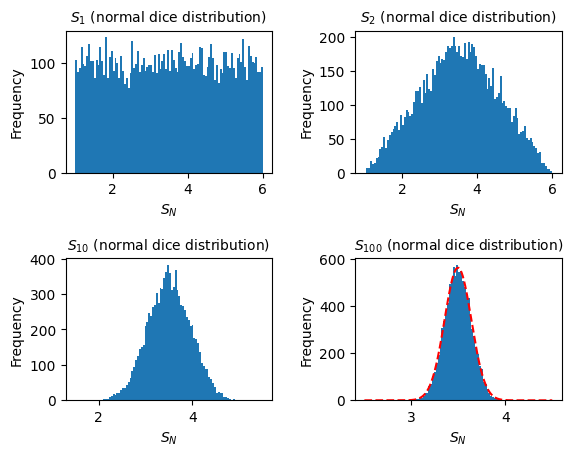

In [ ]:
from scipy.optimize import curve_fit

plt.rc('text', usetex= False)

# Creazione di una figura contenente quattro grafici
fig, axs = plt.subplots(2, 2) 

# Funzione gaussiana utilizzata per il fit
def f(x, a, b, c):  
    return a * np.exp(-b * (x - c) ** 2)

# Funzione di Cauchy-Lorentz utilizzata per il fit
def f_CL (x, a, b, c):
    return (a / np.pi) * (b / ((x - c) ** 2 + b ** 2))

# Funzione per rappresentare gli istogrammi delle medie S_N
def plot(filename, col, bins, a, b, min, max, title, fit = None):
    x = np.loadtxt(filename, usecols=(col), delimiter=' ', unpack='true') 

    # Creazione istogramma
    n_bins = bins
    axs[a,b].hist(x, n_bins, range=(min,max))
    axs[a,b].set_xlabel('$S_N$')
    axs[a,b].set_ylabel('Frequency')
    #axs[a,b].set_yscale('log')
    axs[a,b].set_title(title, fontsize=10)
    #axs[a,b].grid(True)
    
    # Calcolo delle frequenze e dei centri dei bin per effettuare il fit
    if fit is not None:
        counts, bins= np.histogram(x, bins=n_bins, range=(min,max)) 
        bin_centers = (bins[:-1] + bins[1:]) / 2  

        #Fit gaussiano
        if fit == 'Gaussian':
            popt, pcov = curve_fit(f, bin_centers, counts, p0=[1, 1, 3]) # Fit gaussiano
            x_fit = np.linspace(min, max, 1000)  # Punti per una curva liscia
            y_fit = f(x_fit, *popt)
            axs[1,1].plot(x_fit, y_fit, 'r--')  # Linea rossa tratteggiata per il fit

        #Fit Cauchy-Lorentz
        elif fit == 'CL':
            popt, pcov = curve_fit(f_CL, bin_centers, counts, p0=[1, 1, (min+max)/2])
            x_fit = np.linspace(min, max, 1000)
            y_fit = f_CL(x_fit, *popt)
            axs[1,1].plot(x_fit, y_fit, 'r--', label='CL fit')

#Dado standard

plot('Es01.2/outputS1.txt',0,100,0,0,1,6,'$S_1$ (normal dice distribution)')

plot('Es01.2/outputS2.txt',0,100,0,1,1,6,'$S_2$ (normal dice distribution)')

plot('Es01.2/outputS3.txt',0,100,1,0,1.5,5.5,'$S_{10}$ (normal dice distribution)')

plot('Es01.2/outputS4.txt',0,100,1,1,2.5,4.5,'$S_{100}$ (normal dice distribution)', fit = 'Gaussian')

# Regolazione dello spazio tra i grafici
plt.subplots_adjust(wspace=0.4, hspace=0.6)

/var/folders/zv/smc9371s64j3c_gsvywk77r40000gn/T/ipykernel_5434/3972457276.py:10: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * (x - c) ** 2)


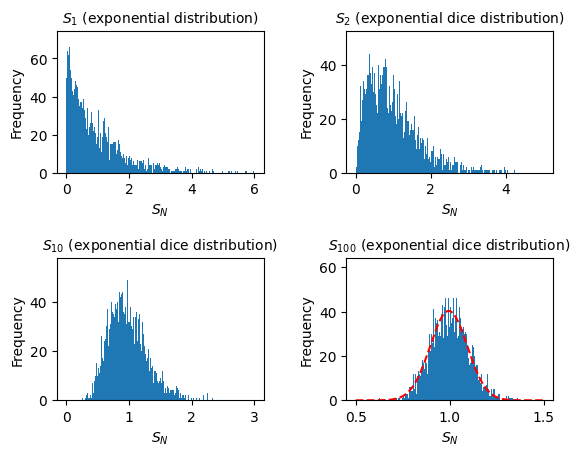

In [11]:
#Dado esponenziale

fig, axs = plt.subplots(2, 2)

plot('Es01.2/outputS1.txt',1,1000,0,0,0,6,'$S_1$ (exponential distribution)')

plot('Es01.2/outputS2.txt',1,1000,0,1,0,5,'$S_2$ (exponential dice distribution)')

plot('Es01.2/outputS3.txt',1,1000,1,0,0,3,'$S_{10}$ (exponential dice distribution)')

plot('Es01.2/outputS4.txt',1,1000,1,1,0.5,1.5,'$S_{100}$ (exponential dice distribution)', fit = 'Gaussian')

plt.subplots_adjust(wspace=0.4, hspace=0.6)

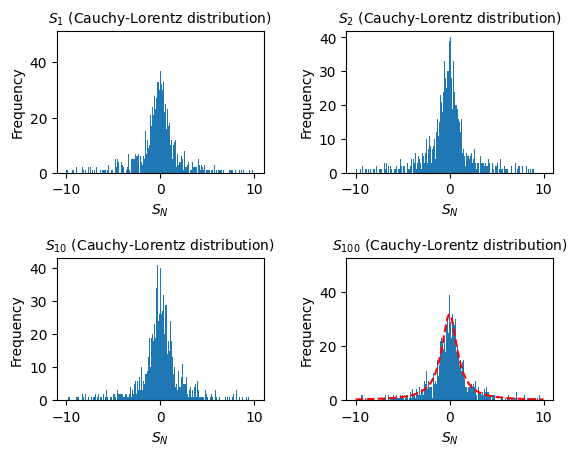

In [12]:
#Dato Lorentziano

fig, axs = plt.subplots(2, 2)

plot('Es01.2/outputS1.txt',2,2000,0,0,-10,10,'$S_1$ (Cauchy-Lorentz distribution)')

plot('Es01.2/outputS2.txt',2,2000,0,1,-10,10,'$S_2$ (Cauchy-Lorentz distribution)')

plot('Es01.2/outputS3.txt',2,2000,1,0,-10,10,'$S_{10}$ (Cauchy-Lorentz distribution)')

plot('Es01.2/outputS4.txt',2,2000,1,1,-10,10,'$S_{100}$ (Cauchy-Lorentz distribution)', fit = 'CL')

plt.subplots_adjust(wspace=0.4, hspace=0.6)


Dai grafici si osserva chiaramente come le distribuzioni uniforme ed esponenziale convergano alla distribuzione gaussiana, mentre la distribuzione di Cauchy-Lorentz converge, come atteso, a una distribuzione di Cauchy-Lorentz.

### <span style= "color: black" > Es01.3

Lo scopo di questo esercizio è simulare l’esperimento di Buffon per stimare il valore di $\pi$.
L’esperimento consiste nel lanciare un ago di lunghezza $L$ ($L=1$) su un piano orizzontale diviso da $n$ ($n=1000$) linee parallele, poste a distanza $d>L$ l’una dall’altra ($d$ è stato scelto uguale a 2).
Contando quante volte l’ago interseca una delle rette ($N_{hit}$), possiamo stimare il valore di $\pi$ tramite la seguente espressione: $$\pi = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d} $$

dove $N_{thr}$ rappresenta il numero di volte in cui l’ago viene lanciato.
Per calcolare il valore di $\pi$ e il relativo errore abbiamo utilizzato il metodo del data blocking, con un totale di 100 blocchi e $10^5$ lanci totali ($N_{thr}$).

Il grafico seguente rappresenta la stima del valore di $\pi$ e la relativa incertezza ottenute dall’esperimento.

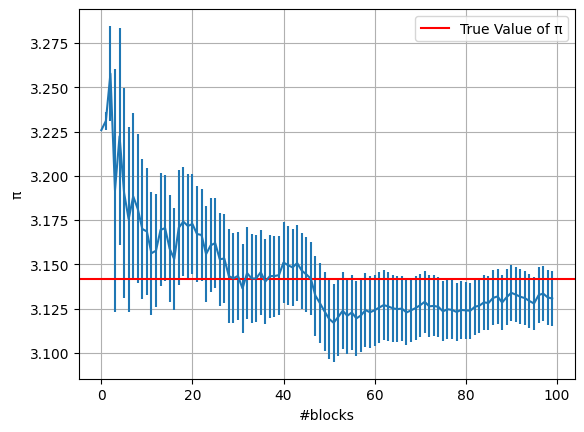

In [ ]:
# Caricamento della stima progressiva di π 
x,f, error = np.loadtxt("Es01.3/output.txt", usecols=(0,1,2), delimiter=' ', unpack='true') 
plt.errorbar(x,f,yerr=error) 
plt.xlabel('#blocks')
plt.ylabel('π')
plt.grid(True)

#Plot del valore teorico di pigreco
pi = np.pi
plt.axhline(y=pi, color='r', label='True Value of π')

plt.legend()  

plt.show() 